# Exploration des données — Comptage vélo à Paris

Ce notebook présente une exploration visuelle des données de comptage cycliste collectées par la Ville de Paris via son réseau de compteurs automatiques.

**Objectif :** comprendre les tendances temporelles et spatiales de la fréquentation cycliste à Paris — par heure, par jour, par mois, et par site de comptage.

**Source de données :** `comptage-velo-donnees-compteurs.csv` — données brutes issues des compteurs installés sur la voirie parisienne (environ 947 000 entrées horaires).

**Visualisations abordées :**
1. Comptage total par jour
2. Comptage total par mois
3. Moyenne horaire par jour
4. Profil moyen par heure de la journée
5. Profil moyen par jour de la semaine
6. Top 10 des sites les plus fréquentés
7. Comparaison du profil horaire entre les top 10 sites
8. Carte de l'intensité moyenne par site

> **Note :** les comptages représentent des passages devant un capteur, et non des cyclistes uniques. Un même vélo peut être comptabilisé plusieurs fois s'il croise plusieurs compteurs.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

In [2]:
# Importation des données brutes
df = pd.read_csv('../data/raw/comptage-velo-donnees-compteurs.csv', sep=';')

In [3]:
df.head()

,Identifiant du compteur,Nom du compteur,Identifiant du site de comptage,Nom du site de comptage,Comptage horaire,Date et heure de comptage,Date d'installation du site de comptage,Lien vers photo du site de comptage,Coordonnées géographiques,Identifiant technique compteur,ID Photos,test_lien_vers_photos_du_site_de_comptage_,id_photo_1,url_sites,type_dimage,mois_annee_comptage
0,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T05:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05
1,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T09:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05
2,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T08:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05
3,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T06:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05
4,100003098-101003098,106 avenue Denfert Rochereau NE-SO,100003098.0,106 avenue Denfert Rochereau,0,2024-05-01T14:00:00+02:00,2012-02-22,https://filer.eco-counter-tools.com/file/09/73...,"48.83507,2.33305",Y2H20114504,https://filer.eco-counter-tools.com/file/09/73...,https://filer.eco-counter-tools.com/file/09/73...,https:,https://www.eco-visio.net/Photos/100003098,jpg,2024-05


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947043 entries, 0 to 947042
Data columns (total 16 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Identifiant du compteur                     913901 non-null  object 
 1   Nom du compteur                             947043 non-null  object 
 2   Identifiant du site de comptage             913901 non-null  float64
 3   Nom du site de comptage                     913901 non-null  object 
 4   Comptage horaire                            947043 non-null  int64  
 5   Date et heure de comptage                   947043 non-null  object 
 6   Date d'installation du site de comptage     913901 non-null  object 
 7   Lien vers photo du site de comptage         904072 non-null  object 
 8   Coordonnées géographiques                   913901 non-null  object 
 9   Identifiant technique compteur              904072 non-null  object 
 

In [5]:
# Conversion de la colonne 'Date et heure de comptage' en datetime en heure locale (Europe/Paris), sans fuseau horaire stocké
df['Date et heure de comptage'] = (
    pd.to_datetime(df['Date et heure de comptage'], utc=True)
    .dt.tz_convert('Europe/Paris')
    .dt.tz_localize(None)
)

In [6]:
df['Date et heure de comptage'].head()

0   2024-05-01 05:00:00
1   2024-05-01 09:00:00
2   2024-05-01 08:00:00
3   2024-05-01 06:00:00
4   2024-05-01 14:00:00
Name: Date et heure de comptage, dtype: datetime64[ns]

## 1) Comptage total de vélos par jour

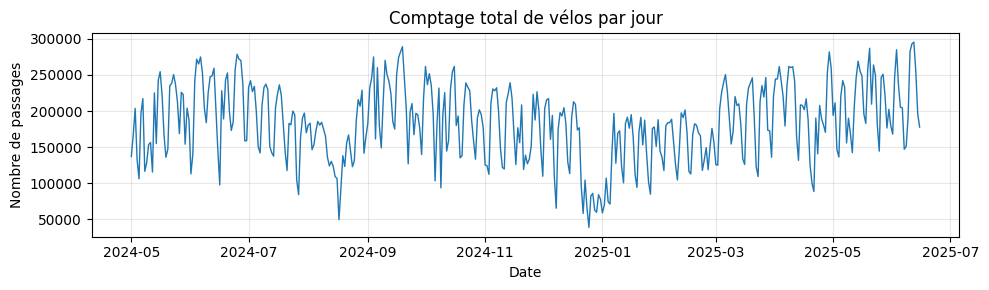

In [7]:
comptage_par_jour = df.groupby(df['Date et heure de comptage'].dt.date)['Comptage horaire'].sum()

x = comptage_par_jour.index
y = comptage_par_jour.values

plt.figure(figsize=(10, 3))
plt.plot(x, y, linewidth=1)
plt.title("Comptage total de vélos par jour")
plt.xlabel("Date")
plt.ylabel("Nombre de passages")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/total_velos_par_jour.png', dpi=150)
plt.show()

Ce graphique affiche le nombre total de passages de vélos par jour sur l’ensemble des compteurs. Il permet de visualiser l’évolution de la fréquentation cycliste dans le temps et de repérer facilement les pics d’activité ainsi que les périodes creuses.

Cependant, cette mesure ne correspond pas au nombre réel de cyclistes : un même vélo peut être compté plusieurs fois s’il passe devant plusieurs compteurs, les dates d’installation différentes peuvent créer des variations artificielles, et certains compteurs peuvent être activés ou désactivés temporairement, ce qui influence les volumes observés. Cette visualisation donne donc une tendance globale, mais doit être interprétée avec prudence.

## 2) Comptage total de vélos par mois

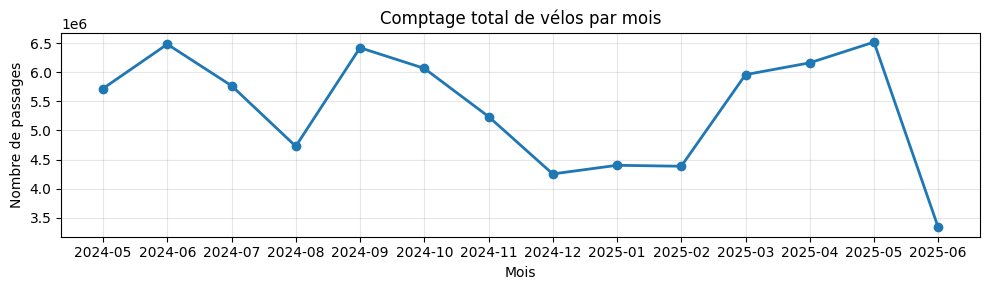

In [8]:
comptage_par_mois = df.groupby('mois_annee_comptage')['Comptage horaire'].sum()

x = comptage_par_mois.index
y = comptage_par_mois.values

plt.figure(figsize=(10, 3))
plt.plot(x, y, linewidth=2, marker='o')
plt.title("Comptage total de vélos par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre de passages")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/total_velos_par_mois.png', dpi=150)
plt.show()

Ce graphique montre le nombre total de passages de vélos par mois sur l’ensemble des compteurs. Il met en évidence les tendances saisonnières de la fréquentation cycliste, en atténuant les fluctuations journalières.

Cependant, comme pour les totaux quotidiens, cette mesure ne correspond pas au nombre unique de cyclistes au fil du temps.

## 3) Moyenne des comptages horaires par jour

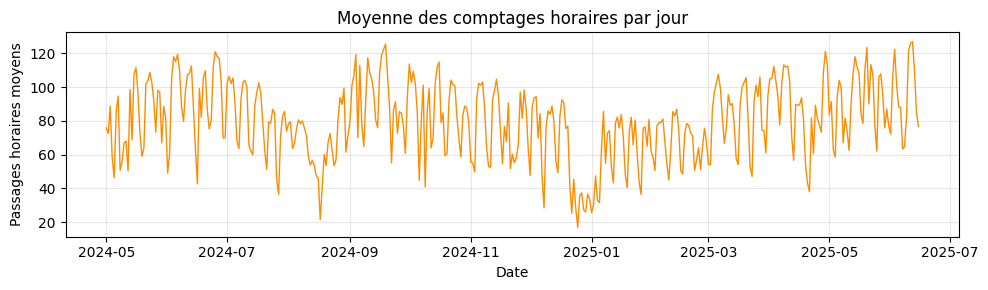

In [9]:
comptage_par_jour_moyen = df.groupby(df['Date et heure de comptage'].dt.date)['Comptage horaire'].mean()

x = comptage_par_jour_moyen.index
y = comptage_par_jour_moyen.values

plt.figure(figsize=(10, 3))
plt.plot(x, y, color='darkorange', linewidth=1)
plt.title("Moyenne des comptages horaires par jour")
plt.xlabel("Date")
plt.ylabel("Passages horaires moyens")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/moyenne_velos_par_jour.png', dpi=150)
plt.show()

Ce graphique présente, pour chaque jour, la moyenne des comptages horaires par compteur, calculée sur l’ensemble des sites et des heures de la journée.

Il permet d’observer l’intensité moyenne du trafic cycliste par compteur et par heure, indépendamment du nombre total de capteurs en service. Cette approche réduit l’effet de la structure du réseau et rend la comparaison temporelle plus pertinente.

## 4) Moyenne des comptages par heure de la journée

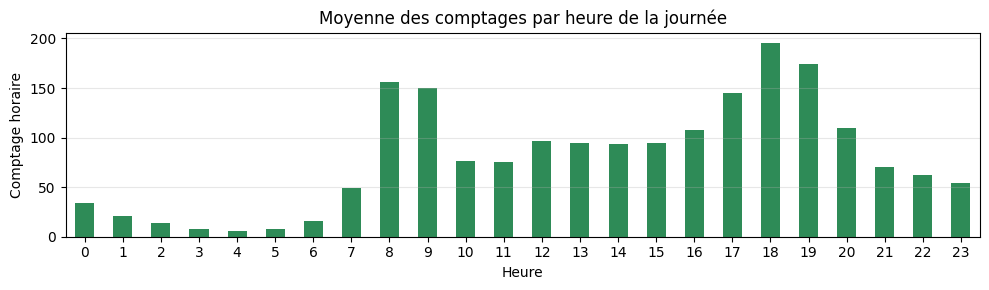

In [10]:
df['Heure'] = df['Date et heure de comptage'].dt.hour

comptage_par_heure_moyen = df.groupby('Heure')['Comptage horaire'].mean()

plt.figure(figsize=(10, 3))
comptage_par_heure_moyen.plot(kind='bar', color='seagreen')
plt.title("Moyenne des comptages par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Comptage horaire")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/moyenne_velos_par_heure.png', dpi=150)
plt.show()

Ce graphique montre la moyenne des comptages horaires en fonction de l’heure de la journée, calculée sur l’ensemble des compteurs.

Il permet d’identifier les moments de la journée les plus fréquentés, notamment les pics typiques aux heures de pointe et les périodes de faible activité nocturne.

Cette mesure est indépendante du nombre de jours ou de compteurs actifs, mais elle reste sensible aux différences d’intensité entre sites et aux éventuelles coupures de capteurs.

## 5) Moyenne des comptages par jour de la semaine

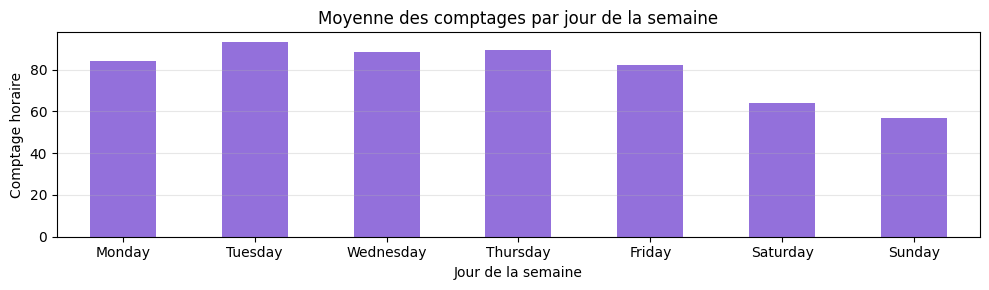

In [11]:
df['Jour de la semaine'] = df['Date et heure de comptage'].dt.day_name()

comptage_par_jour_de_semaine = df.groupby('Jour de la semaine')['Comptage horaire'].mean()

ordre_jours = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
comptage_par_jour_de_semaine = comptage_par_jour_de_semaine.reindex(ordre_jours)

plt.figure(figsize=(10, 3))
comptage_par_jour_de_semaine.plot(kind='bar', color='mediumpurple')
plt.title("Moyenne des comptages par jour de la semaine")
plt.xlabel("Jour de la semaine")
plt.ylabel("Comptage horaire")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/moyenne_velos_par_jour_de_semaine.png', dpi=150)
plt.show()

Ce graphique présente la moyenne des comptages horaires en fonction du jour de la semaine, sur l’ensemble des compteurs.

Il met en évidence les variations de fréquentation entre jours ouvrés et week-ends, révélant par exemple une activité plus marquée en semaine et plus diffuse les samedis et dimanches.

Cette mesure reflète les comportements de déplacement typiques, mais reste influencée par la localisation et l’activité variable des compteurs.

## 6) Top 10 des sites de comptage - Moyenne horaire

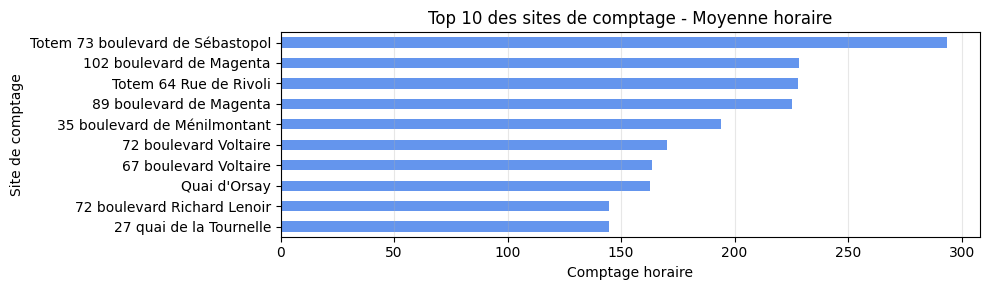

In [12]:
comptage_par_site = (
    df.groupby('Nom du site de comptage')['Comptage horaire']
    .mean()
    .sort_values(ascending=False)
)

top_sites = comptage_par_site.head(10)

plt.figure(figsize=(10, 3))
top_sites.iloc[::-1].plot(kind='barh', color='cornflowerblue')
plt.title("Top 10 des sites de comptage - Moyenne horaire")
plt.xlabel("Comptage horaire")
plt.ylabel("Site de comptage")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/top_10_sites_moyenne_horaire.png', dpi=150)
plt.show()

Ce graphique montre les 10 sites de comptage les plus fréquentés, classés selon la moyenne horaire des passages enregistrés.

Il permet d'observer l’activité moyenne par site, mais ne tient pas compte des différences de durée d’installation ou de fonctionnement des capteurs.

## 7) Comparaison de la moyenne horaire par site (Top 10)

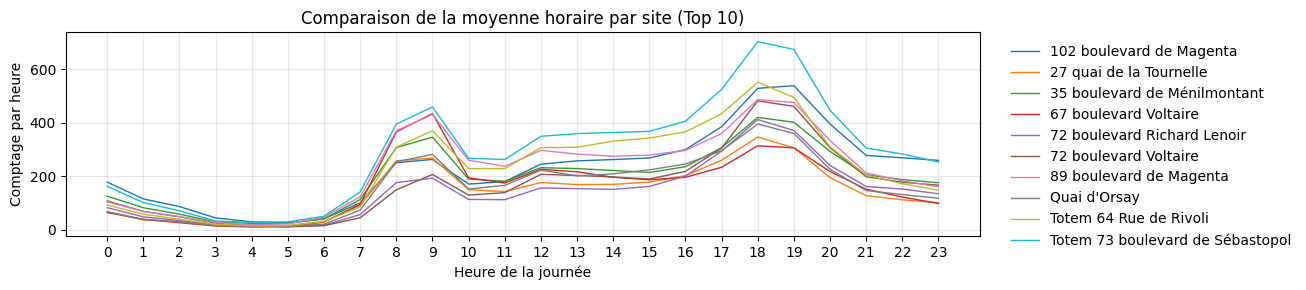

In [13]:
top_sites = (
    df.groupby('Nom du site de comptage')['Comptage horaire']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

df_filtre = df[df['Nom du site de comptage'].isin(top_sites)].copy()

df_filtre['Heure'] = df_filtre['Date et heure de comptage'].dt.hour

comparaison = (
    df_filtre.groupby(['Nom du site de comptage', 'Heure'])['Comptage horaire']
    .mean()
    .reset_index()
)

wide = comparaison.pivot(
    index='Heure',
    columns='Nom du site de comptage',
    values='Comptage horaire',
)

plt.figure(figsize=(10, 3))
for col in wide.columns:
    plt.plot(wide.index, wide[col], linewidth=1, label=col)
plt.title("Comparaison de la moyenne horaire par site (Top 10)")
plt.xlabel("Heure de la journée")
plt.ylabel("Comptage par heure")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.legend(
    ncol=1,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False,
)
plt.savefig('../reports/figures/top_10_sites_moyenne_par_heure.png', dpi=150, bbox_inches='tight')
plt.show()

Ce graphique compare le profil horaire moyen des 10 sites de comptage les plus fréquentés.

On observe que l’intensité varie d’un site à l’autre, en fonction de leur localisation et de leur niveau d’activité.

Cependant, la tendance générale reste très similaire : une montée progressive en début de matinée, un pic aux heures de pointe, une baisse en journée et une remontée en fin d’après-midi.

## 8) Intensité moyenne des comptages par site

In [14]:
df_coord = (
    df.groupby(['Nom du site de comptage', 'Coordonnées géographiques'])['Comptage horaire']
    .mean()
    .reset_index()
)

df_coord[['Lat', 'Lon']] = (
    df_coord['Coordonnées géographiques'].str.split(',', expand=True).astype(float)
)

fig = px.scatter_map(
    df_coord,
    lat='Lat',
    lon='Lon',
    size='Comptage horaire',
    hover_name='Nom du site de comptage',
    zoom=11,
    title="Intensité moyenne des comptages par site",
)

fig.update_layout(height=700, width=900)

fig.write_image(
    '../reports/figures/intensite_moyenne_comptages_par_site.png',
    scale=2,
)

fig.show()

Cette carte montre l’intensité moyenne des comptages par site, représentée par la taille des bulles.

Elle permet de visualiser la répartition spatiale de la fréquentation cycliste et de repérer les zones les plus actives.

On constate que certains axes concentrent une activité particulièrement élevée, tandis que d’autres sites enregistrent des volumes plus faibles, reflétant la structure du réseau cyclable et les flux de déplacements dans la ville.

Enfin, certains arrondissements ne possèdent aucun compteur, ou très peu.